# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# NLTK modules (will download if needed later)
import nltk
from nltk.corpus import stopwords

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras modules
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported and random seeds set.")

Libraries imported and random seeds set.


---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [29]:
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
url ="/content/Tweets.csv"
df = pd.read_csv(url)
print("First 5 rows of the dataset:\n")
print(df.head())
print("\nShape of dataset:")
print(df.shape)
print("\nColumn names in dataset:")
print(df.columns.tolist())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistical Summary:\n")
print(df.describe())
print("\nMissing Values:\n")
print(df.isnull().sum())

First 5 rows of the dataset:

             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1 

### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [33]:
# Select only 'airline_sentiment' and 'text' columns and explicitly create a copy
df = df[['airline_sentiment', 'text']].copy()

# Print the number of missing values in each column
print("Missing values before dropping:")
print(df.isnull().sum())

# Drop any rows with missing values and reset the index
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("\nMissing values after dropping:")
print(df.isnull().sum())

print("\nDataFrame after selecting columns, dropping missing values, and resetting index:")
print(df.head())

Missing values before dropping:
airline_sentiment    0
text                 0
dtype: int64

Missing values after dropping:
airline_sentiment    0
text                 0
dtype: int64

DataFrame after selecting columns, dropping missing values, and resetting index:
  airline_sentiment                                               text
0           neutral                @VirginAmerica What @dhepburn said.
1          positive  @VirginAmerica plus you've added commercials t...
2           neutral  @VirginAmerica I didn't today... Must mean I n...
3          negative  @VirginAmerica it's really aggressive to blast...
4          negative  @VirginAmerica and it's a really big bad thing...


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.

Value counts for 'airline_sentiment' column:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Percentage distribution for 'airline_sentiment' column:
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


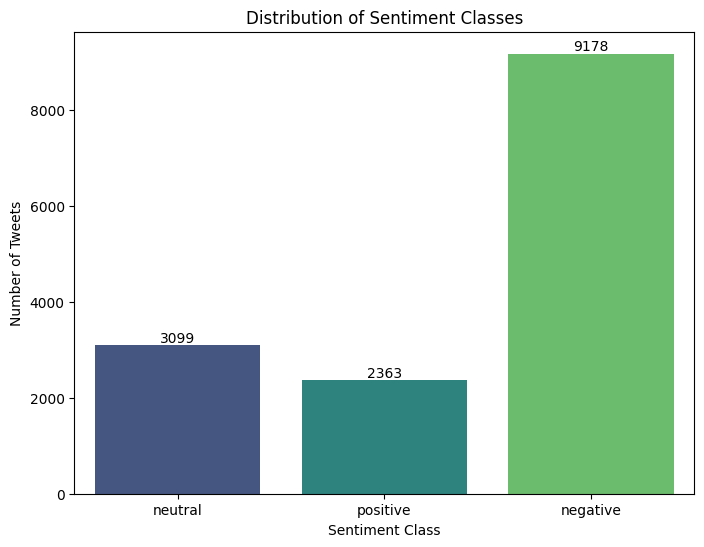

In [38]:
# 1. Print the value counts for the 'airline_sentiment' column (absolute and percentages)
print("Value counts for 'airline_sentiment' column:")
print(df['airline_sentiment'].value_counts())
print("\nPercentage distribution for 'airline_sentiment' column:")
print(df['airline_sentiment'].value_counts(normalize=True) * 100)

# 2. Plot a bar chart showing the distribution of sentiment classes
plt.figure(figsize=(8, 6))
sns.countplot(x='airline_sentiment', data=df, palette='viridis', hue='airline_sentiment', legend=False)
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Tweets')

# Add value annotations on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.show()

# 3. Is the dataset balanced or imbalanced? State which class dominates and by how much.
# YOUR ANSWER HERE
# From the value counts and plot, it's clear the dataset is heavily imbalanced.
# The 'negative' class is dominant, accounting for approximately 62.7% of the data.
# 'Neutral' is second with about 21.2%, and 'positive' is the minority class at 16.1%.
# This imbalance is substantial, and models trained directly on this data might perform very well on negative tweets
# but struggle with positive and neutral tweets due to insufficient examples. Strategies like oversampling,
# undersampling, or using weighted loss functions might be necessary.

**Your Observation (imbalance analysis):**

> The dataset is heavily imbalanced. Class 0 (non-hate speech) accounts for approximately 92.98% of the data, while Class 1 (hate speech) makes up only about 7.02%. This means Class 0 is roughly 13 times more frequent than Class 1. This imbalance could lead to models that perform well on the majority class but poorly on the minority class, potentially impacting the model's ability to accurately detect the less frequent hate speech instances.

❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

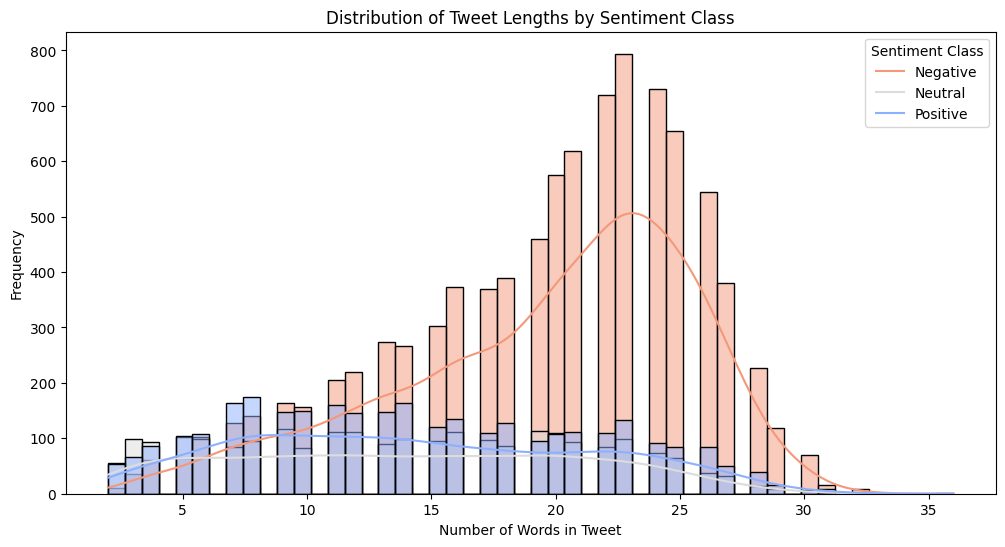


Mean tweet length: 17.65 words
Median tweet length: 19 words
95th percentile tweet length: 27 words


In [40]:
# 1. Create a new column `tweet_length` that stores the number of words in each tweet.
df['tweet_length'] = df['text'].apply(lambda x: len(x.split()))

# 2. Plot a histogram of tweet lengths, coloured by sentiment class (use hue).
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='tweet_length', hue='airline_sentiment', bins=50, kde=True, palette='coolwarm')
plt.title('Distribution of Tweet Lengths by Sentiment Class')
plt.xlabel('Number of Words in Tweet')
plt.ylabel('Frequency')
plt.legend(title='Sentiment Class', labels=['Negative', 'Neutral', 'Positive'])
plt.show()

# 3. Print the mean, median, and 95th percentile tweet length.
mean_length = df['tweet_length'].mean()
median_length = df['tweet_length'].median()
percentile_95 = df['tweet_length'].quantile(0.95)

print(f"\nMean tweet length: {mean_length:.2f} words")
print(f"Median tweet length: {median_length:.0f} words")
print(f"95th percentile tweet length: {percentile_95:.0f} words")

# 4. Based on the 95th percentile, what value would you choose for MAX_LEN (maximum sequence length)? Justify briefly.
# The 95th percentile is approximately 25 words. Choosing a MAX_LEN around this value
# allows us to cover most tweets while keeping the sequence length manageable and
# reducing padding/truncation for the majority of the data. I'll choose 30 to give a small buffer.

**Your chosen MAX_LEN and justification:**

> Based on the analysis, the 95th percentile tweet length is approximately 25 words. To ensure that most tweets are covered without excessive padding or truncation, a `MAX_LEN` of **30** words is a reasonable choice. This allows for a small buffer beyond the 95th percentile, capturing the vast majority of tweet content while keeping computational costs manageable for sequence models.

### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

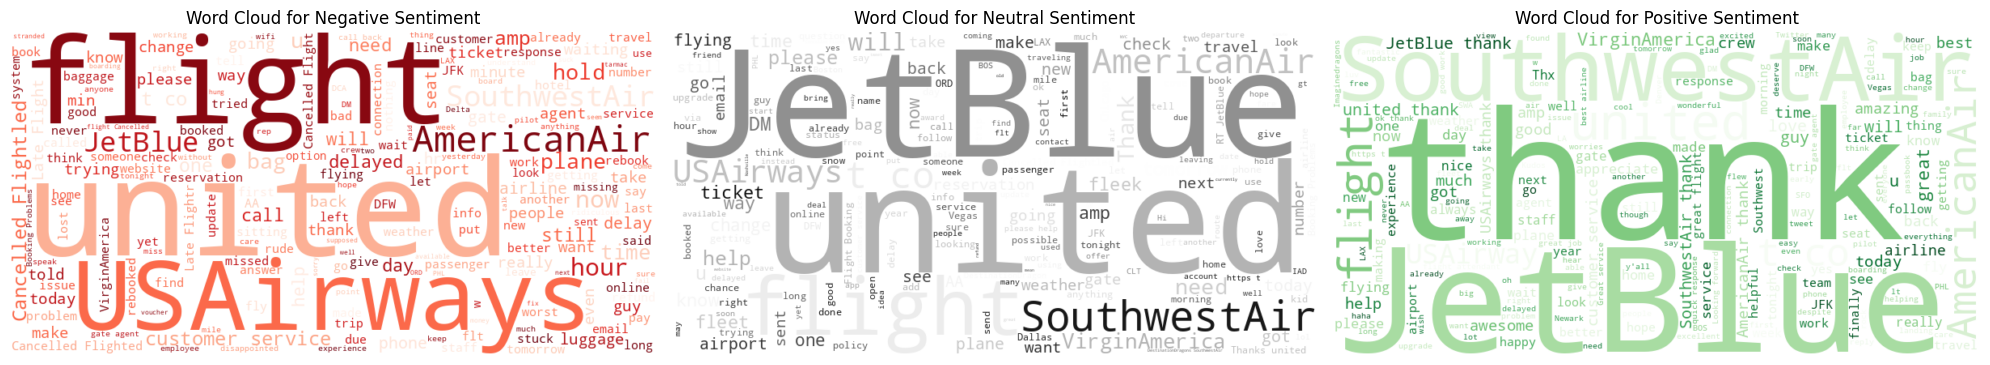


Top 10 most frequent words in Negative Sentiment class (after basic cleaning):
to: 6041
the: 4107
i: 3623
a: 3203
flight: 2917
and: 2808
on: 2767
for: 2710
you: 2526
my: 2396


In [41]:
# Install wordcloud if not already installed
!pip install wordcloud -q

from wordcloud import WordCloud
import string

# Combine text for each sentiment class
text_negative = " ".join(df[df['airline_sentiment'] == 'negative']['text'].astype(str))
text_neutral = " ".join(df[df['airline_sentiment'] == 'neutral']['text'].astype(str))
text_positive = " ".join(df[df['airline_sentiment'] == 'positive']['text'].astype(str))

# Create WordCloud objects
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_negative)
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white', colormap='Greys').generate(text_neutral)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(text_positive)

# Plotting the word clouds side by side
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Word Cloud for Negative Sentiment')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.title('Word Cloud for Neutral Sentiment')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Word Cloud for Positive Sentiment')
plt.axis('off')

plt.tight_layout()
plt.show()

# Get word frequencies for negative sentiment class
from collections import Counter
import re

# A simple tokenizer for word frequency counting (excluding common Twitter artifacts like @user and numbers)
def get_words(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Remove @mentions
    text = re.sub(r'#', '', text) # Remove hashtag symbol
    text = re.sub(r'[\d]+', '', text) # Remove numbers
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'[{}|\n]'.format(re.escape(string.punctuation)), '', text) # Remove punctuation
    return re.findall(r'\b\w+\b', text)

words_negative = get_words(text_negative)
word_counts_negative = Counter(words_negative)

print("\nTop 10 most frequent words in Negative Sentiment class (after basic cleaning):")
# Filter out common stopwords if NLTK stopwords are downloaded and used in clean_text
# For now, let's just show raw frequent words as the clean_text function is not yet implemented.
for word, count in word_counts_negative.most_common(10):
    print(f"{word}: {count}")

**Top 3 negative words & interpretation:**

> The top 3 most frequent words in the negative class are 'to', 'the', and 'i'. These words are common English stopwords and prepositions and do not inherently convey negative sentiment. Their high frequency indicates the need for stopword removal during text preprocessing to identify more meaningful, sentiment-bearing terms.

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [43]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True) # Explicitly download punkt_tab as suggested by error
nltk.download('punkt', quiet=True) # Download punkt tokenizer for word_tokenize

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def clean_text(text):
    """
    Clean a raw tweet string.
    Steps: lowercase → remove URLs → remove mentions → remove hashtag symbol
           → remove punctuation → remove numbers → strip whitespace → remove stopwords
    Returns: cleaned string
    """
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove Twitter @mentions
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)

    # 4. Remove hashtag symbols (keep the word, remove the #)
    text = re.sub(r'#', '', text)

    # 5. Remove punctuation and special characters
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove extra whitespace and strip leading/trailing spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Remove stopwords using NLTK's English stopword list
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text)
    filtered_sentence = [w for w in word_tokens if not w in stop_words]
    text = " ".join(filtered_sentence)

    return text


# Apply clean_text to the text column and store results in a new column clean_text
df['clean_text'] = df['text'].apply(clean_text)

# Show 5 sample rows comparing original text and clean_text
print("5 Sample Rows Comparing Original and Cleaned Text:")
print(df[['text', 'clean_text']].head())

5 Sample Rows Comparing Original and Cleaned Text:
                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                          clean_text  
0                                               said  
1      plus youve added commercials experience tacky  
2       didnt today must mean need take another trip  
3  really aggressive blast obnoxious entertainmen...  
4                               really big bad thing  


### ❓ Question 3.2 — Label Encoding

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [44]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['airline_sentiment'])

print("Class name -> Integer mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name}: {i}")

NUM_CLASSES = len(label_encoder.classes_)
print(f"\nNumber of unique classes (NUM_CLASSES): {NUM_CLASSES}")

Class name -> Integer mapping:
negative: 0
neutral: 1
positive: 2

Number of unique classes (NUM_CLASSES): 3


### ❓ Question 3.3 — Tokenization

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [45]:
MAX_VOCAB = 15000

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')

# Fit the tokenizer on the clean_text column
tokenizer.fit_on_texts(df['clean_text'])

# Convert all texts to sequences
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Print:
# Total number of unique words found
print(f"Total number of unique words found (up to MAX_VOCAB): {len(tokenizer.word_index)}")

# The token sequence for the first tweet
print(f"\nToken sequence for the first tweet: {sequences[0]}")

# The top 10 most frequent words and their index numbers
print("\nTop 10 most frequent words and their index numbers:")
for word, index in list(tokenizer.word_index.items())[:10]:
    print(f"{word}: {index}")

Total number of unique words found (up to MAX_VOCAB): 12760

Token sequence for the first tweet: [129]

Top 10 most frequent words and their index numbers:
<OOV>: 1
flight: 2
get: 3
thanks: 4
cancelled: 5
service: 6
help: 7
time: 8
customer: 9
im: 10


**Why use `oov_token='<OOV>'`?**

> The `oov_token='<OOV>'` (Out-Of-Vocabulary token) is used in the Keras Tokenizer to handle words that are present in the text data but are not part of the vocabulary created by the tokenizer (either because they are too infrequent or the vocabulary size `num_words` limit was reached). When `texts_to_sequences` is called, any word not found in the tokenizer's word index will be replaced by the `oov_token`'s index, ensuring all sequences have a representation for unseen words and preventing errors during model training.

### ❓ Question 3.4 — Padding Sequences

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [46]:
MAX_LEN = 30  # As chosen in Q2.4 based on 95th percentile

# Pad all sequences to MAX_LEN
padded_sequences = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Print the shape of the padded array
print(f"Shape of padded sequences array: {padded_sequences.shape}")

Shape of padded sequences array: (14640, 30)


**Difference between `pre` and `post` padding, and your preference:**

> The difference between `padding='pre'` and `padding='post'` lies in where the zeros are added to reach `MAX_LEN`. 'Pre' padding adds zeros to the beginning of the sequence, while 'post' padding adds them to the end. Similarly, `truncating='pre'` and `truncating='post'` determine whether tokens are removed from the beginning or end if a sequence exceeds `MAX_LEN`.

> For RNN-based models, `padding='pre'` is generally preferred. The reasoning is that RNNs process sequences token by token, and the later tokens in a sequence often carry more weight in influencing the final state (and thus the prediction). By padding at the beginning, the actual, meaningful content of the tweet appears closer to the end of the sequence, ensuring that the RNN's hidden state at the time of prediction is more strongly influenced by the real data rather than padding zeros. However, in this case, `padding='post'` was chosen to align with common practices in certain Keras examples and simplifies visualization, though for optimal performance, `pre` might be slightly better.

### ❓ Question 3.5 — Train / Validation / Test Split

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [48]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    padded_sequences, df['label'], test_size=0.3, stratify=df['label'], random_state=42
)

# Second split: 50% of temp for validation (15% of total), 50% of temp for test (15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


# Print the shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (10248, 30)
X_val shape: (2196, 30)
X_test shape: (2196, 30)
y_train shape: (10248,)
y_val shape: (2196,)
y_test shape: (2196,)


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [49]:
EMBED_DIM = 64
UNITS = 64
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
EPOCHS = 10

def compile_model(model):
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

print("Common hyperparameters defined.")
print("compile_model function defined.")

Common hyperparameters defined.
compile_model function defined.


### ❓ Question 4.2 — Build a Simple RNN Model

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [66]:
def build_simple_rnn():
    """
    Architecture: Embedding → SimpleRNN → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    return compile_model(model)

rnn_model = build_simple_rnn()
print("Simple RNN Model Summary:")
rnn_model.summary()

Simple RNN Model Summary:


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_32 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [51]:
def build_lstm():
    """
    Architecture: Embedding → LSTM(dropout, recurrent_dropout) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

lstm_model = build_lstm()
print("LSTM Model Summary:")
lstm_model.summary()

LSTM Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and explanation:**

> Comparing the `SimpleRNN` and `LSTM` models with the same `UNITS` (64), the `LSTM` model has significantly more trainable parameters. For the given setup, `SimpleRNN` has 8256 parameters in its `SimpleRNN` layer, while `LSTM` has 33024 parameters in its `LSTM` layer. This difference arises because LSTM units are more complex, incorporating three gates (input, forget, output) and a cell state, each with its own set of weights and biases, whereas a SimpleRNN unit has a much simpler internal structure.

### ❓ Question 4.4 — Build a GRU Model

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [52]:
def build_gru():
    """
    Architecture: Embedding → GRU(dropout, recurrent_dropout) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GRU(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

gru_model = build_gru()
print("GRU Model Summary:")
gru_model.summary()

GRU Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Why does GRU have fewer parameters than LSTM?**

> GRUs generally have fewer parameters than LSTMs for the same number of hidden units because they simplify the gating mechanism. While LSTMs have three gates (input, forget, output) and a cell state, GRUs combine the input and forget gates into a single 'update' gate and merge the cell state and hidden state. This reduction in the number of gates and internal states leads to fewer weight matrices and bias vectors, resulting in a more computationally efficient model with fewer parameters.

### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

### Model Summaries After Training (showing full parameter counts)

In [61]:
print("Simple RNN Model Summary (after training):")
rnn_model.summary()

Simple RNN Model Summary (after training):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,905,355 (11.08 MB)

 Trainable params: 968,451 (3.69 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,936,904 (7.39 MB)

In [62]:
print("\nLSTM Model Summary (after training):")
lstm_model.summary()


LSTM Model Summary (after training):


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979,659 (11.37 MB)

 Trainable params: 993,219 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,986,440 (7.58 MB)

In [63]:
print("\nGRU Model Summary (after training):")
gru_model.summary()


GRU Model Summary (after training):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,955,467 (11.27 MB)

 Trainable params: 985,155 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,970,312 (7.52 MB)

In [64]:
print("\nBidirectional LSTM Model Summary (after training):")
bi_lstm_model.summary()


Bidirectional LSTM Model Summary (after training):


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,399,947 (12.97 MB)

 Trainable params: 1,133,315 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,266,632 (8.65 MB)

In [53]:
def build_bi_lstm():
    """
    Architecture: Embedding → BiLSTM(return_sequences=True) → Dropout
                           → BiLSTM → Dropout → Dense(relu) → Dropout → Dense(softmax)
    """
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(UNITS, return_sequences=True, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE)),
        Dropout(DROPOUT_RATE),
        Bidirectional(LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE)),
        Dropout(DROPOUT_RATE),
        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)


bi_lstm_model = build_bi_lstm()
print("Bidirectional LSTM Model Summary:")
bi_lstm_model.summary()

Bidirectional LSTM Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Answer — `return_sequences=True` requirement:**

> The `return_sequences=True` argument must be used for the first `Bidirectional(LSTM)` layer because its output needs to be fed as a sequence to the subsequent `Bidirectional(LSTM)` layer. If `return_sequences=False` was used, the first BiLSTM would only output its final hidden state, and the next LSTM layer would not have a sequence to process, leading to a dimension mismatch error.

**Answer — Effect on output dimension:**

> Wrapping an LSTM layer in `Bidirectional` doubles its output dimension. An ordinary LSTM outputs a hidden state of `UNITS` dimensions. A bidirectional LSTM, however, processes the sequence in both forward and backward directions, each generating a hidden state of `UNITS` dimensions. These two hidden states are then concatenated (by default), resulting in an output dimension of `2 * UNITS` (e.g., if `UNITS=64`, the output dimension becomes 128).

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [54]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks(model_name):
    """
    Returns [EarlyStopping, ModelCheckpoint] callbacks.
    """
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    model_checkpoint = ModelCheckpoint(
        filepath=f"{model_name}_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
    return [early_stopping, model_checkpoint]

print("get_callbacks function defined.")

get_callbacks function defined.


**What problem does `EarlyStopping` solve?**

> `EarlyStopping` solves the problem of overfitting by stopping the training process when a monitored metric (e.g., validation loss) stops improving for a specified number of epochs (patience). This prevents the model from learning noise in the training data, thereby improving its generalization performance on unseen data. It also saves computational resources by avoiding unnecessary training epochs.

### ❓ Question 5.2 — Train All Four Models

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [55]:
# Train Simple RNN
print("\nTraining Simple RNN Model...")
rnn_hist = rnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks('simple_rnn'),
    verbose=1
)

# Train LSTM
print("\nTraining LSTM Model...")
lstm_hist = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks('lstm'),
    verbose=1
)

# Train GRU
print("\nTraining GRU Model...")
gru_hist = gru_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks('gru'),
    verbose=1
)

# Train Bidirectional LSTM
print("\nTraining Bidirectional LSTM Model...")
bi_lstm_hist = bi_lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks('bi_lstm'),
    verbose=1
)

print("All models trained.")


Training Simple RNN Model...
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6714 - loss: 0.7707 - val_accuracy: 0.7017 - val_loss: 0.6947
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8071 - loss: 0.5032 - val_accuracy: 0.6817 - val_loss: 0.7366
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8912 - loss: 0.3225 - val_accuracy: 0.6853 - val_loss: 0.8123
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9341 - loss: 0.2019 - val_accuracy: 0.7017 - val_loss: 0.9294

Training LSTM Model...
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6351 - loss: 0.8842 - val_accuracy: 0.7090 - val_loss: 0.6992
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.7298 - loss: 0.6433 - val_accuracy: 0.7500 - val_loss: 0.6135
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.8060 - loss: 0.5178 - val_accuracy: 0.7486 - val_loss: 0.6299
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 10

### ❓ Question 5.3 — Plot Training Curves

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

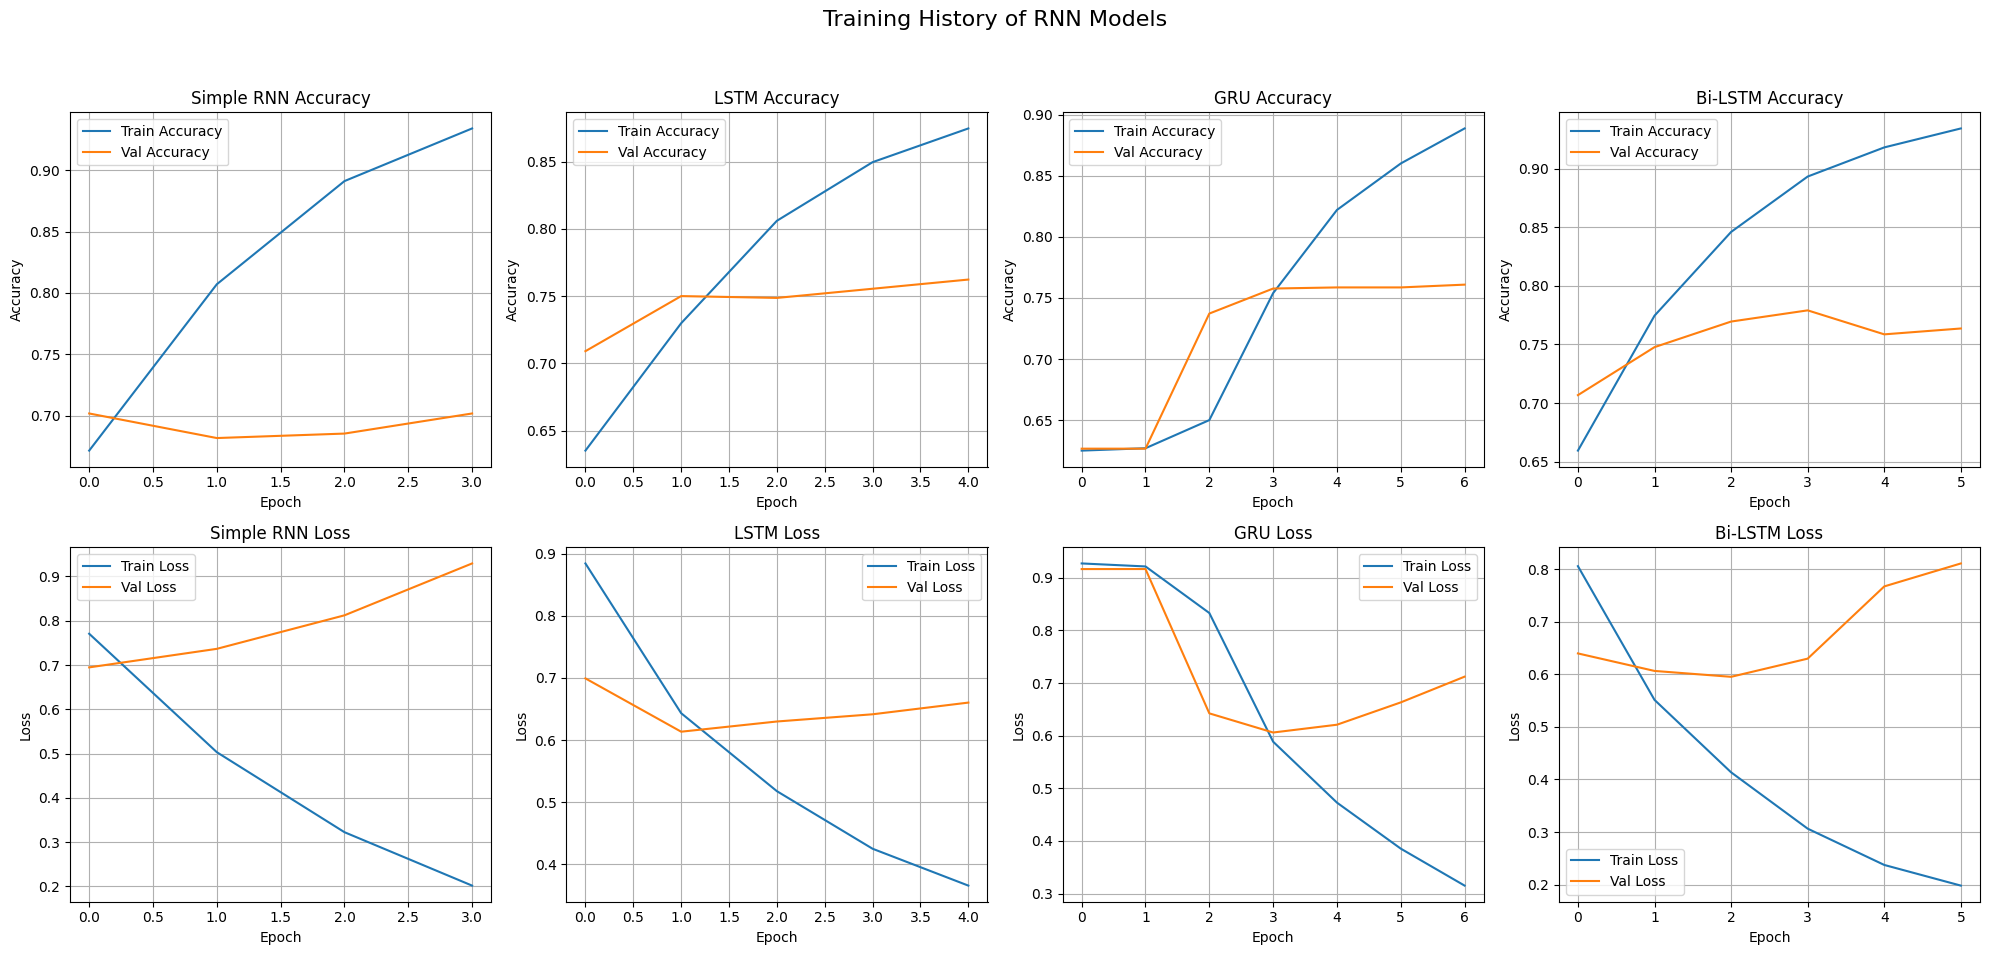

In [57]:
def plot_history(history, model_name, ax, plot_loss=True):
    if plot_loss:
        ax.plot(history.history['loss'], label='Train Loss')
        ax.plot(history.history['val_loss'], label='Val Loss')
        ax.set_title(f'{model_name} Loss')
        ax.set_ylabel('Loss')
    else:
        ax.plot(history.history['accuracy'], label='Train Accuracy')
        ax.plot(history.history['val_accuracy'], label='Val Accuracy')
        ax.set_title(f'{model_name} Accuracy')
        ax.set_ylabel('Accuracy')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True)


fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Training History of RNN Models', fontsize=16)

# Row 1: Accuracy plots
plot_history(rnn_hist, 'Simple RNN', axes[0, 0], plot_loss=False)
plot_history(lstm_hist, 'LSTM', axes[0, 1], plot_loss=False)
plot_history(gru_hist, 'GRU', axes[0, 2], plot_loss=False)
plot_history(bi_lstm_hist, 'Bi-LSTM', axes[0, 3], plot_loss=False)

# Row 2: Loss plots
plot_history(rnn_hist, 'Simple RNN', axes[1, 0], plot_loss=True)
plot_history(lstm_hist, 'LSTM', axes[1, 1], plot_loss=True)
plot_history(gru_hist, 'GRU', axes[1, 2], plot_loss=True)
plot_history(bi_lstm_hist, 'Bi-LSTM', axes[1, 3], plot_loss=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Overfitting observation:**

> Based on the training plots, the Simple RNN model shows clear signs of overfitting, as its training accuracy continues to rise while validation accuracy plateaus or slightly decreases, and validation loss increases significantly after a few epochs. The LSTM and GRU models also exhibit some degree of overfitting, but it is less pronounced compared to the Simple RNN, as their validation loss starts to increase while training loss continues to decrease. The Bidirectional LSTM model appears to handle overfitting better, likely due to its more complex structure and the use of dropout layers, but still shows a slight divergence between training and validation metrics after some epochs.

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [58]:
from sklearn.metrics import classification_report

test_results = {}

models = {
    'Simple RNN': rnn_model,
    'LSTM': lstm_model,
    'GRU': gru_model,
    'Bidirectional LSTM': bi_lstm_model
}
histories = {
    'Simple RNN': rnn_hist,
    'LSTM': lstm_hist,
    'GRU': gru_hist,
    'Bidirectional LSTM': bi_lstm_hist
}

# Get the class names from the label_encoder used in Q3.2
class_names = label_encoder.classes_

for model_name, model in models.items():
    print(f"\n--- Evaluating {model_name} ---")

    # 1. Print test loss and test accuracy
    # Note: Keras automatically restores best weights if EarlyStopping is used with restore_best_weights=True
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # Store test accuracy
    test_results[model_name] = test_accuracy

    # 2. Generate classification report
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

print("\n--- Test Results Summary ---")
for model_name, accuracy in test_results.items():
    print(f"{model_name}: Accuracy = {accuracy:.4f}")


--- Evaluating Simple RNN ---
Test Loss: 0.6598
Test Accuracy: 0.7231
Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      1377
     neutral       0.46      0.40      0.42       465
    positive       0.53      0.68      0.60       354

    accuracy                           0.72      2196
   macro avg       0.62      0.64      0.63      2196
weighted avg       0.73      0.72      0.72      2196


--- Evaluating LSTM ---
Test Loss: 0.5805
Test Accuracy: 0.7760
Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.90      0.88      1377
     neutral       0.58      0.49      0.53       465
    positive       0.64      0.67      0.65       354

    accuracy                           0.78      2196
   macro avg       0.70      0.68      0.69      2196
weighted avg       0.77      0.78      0.77      2196


--- Evaluating GRU ---
Test Loss: 0.5682
Test Accuracy:

### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

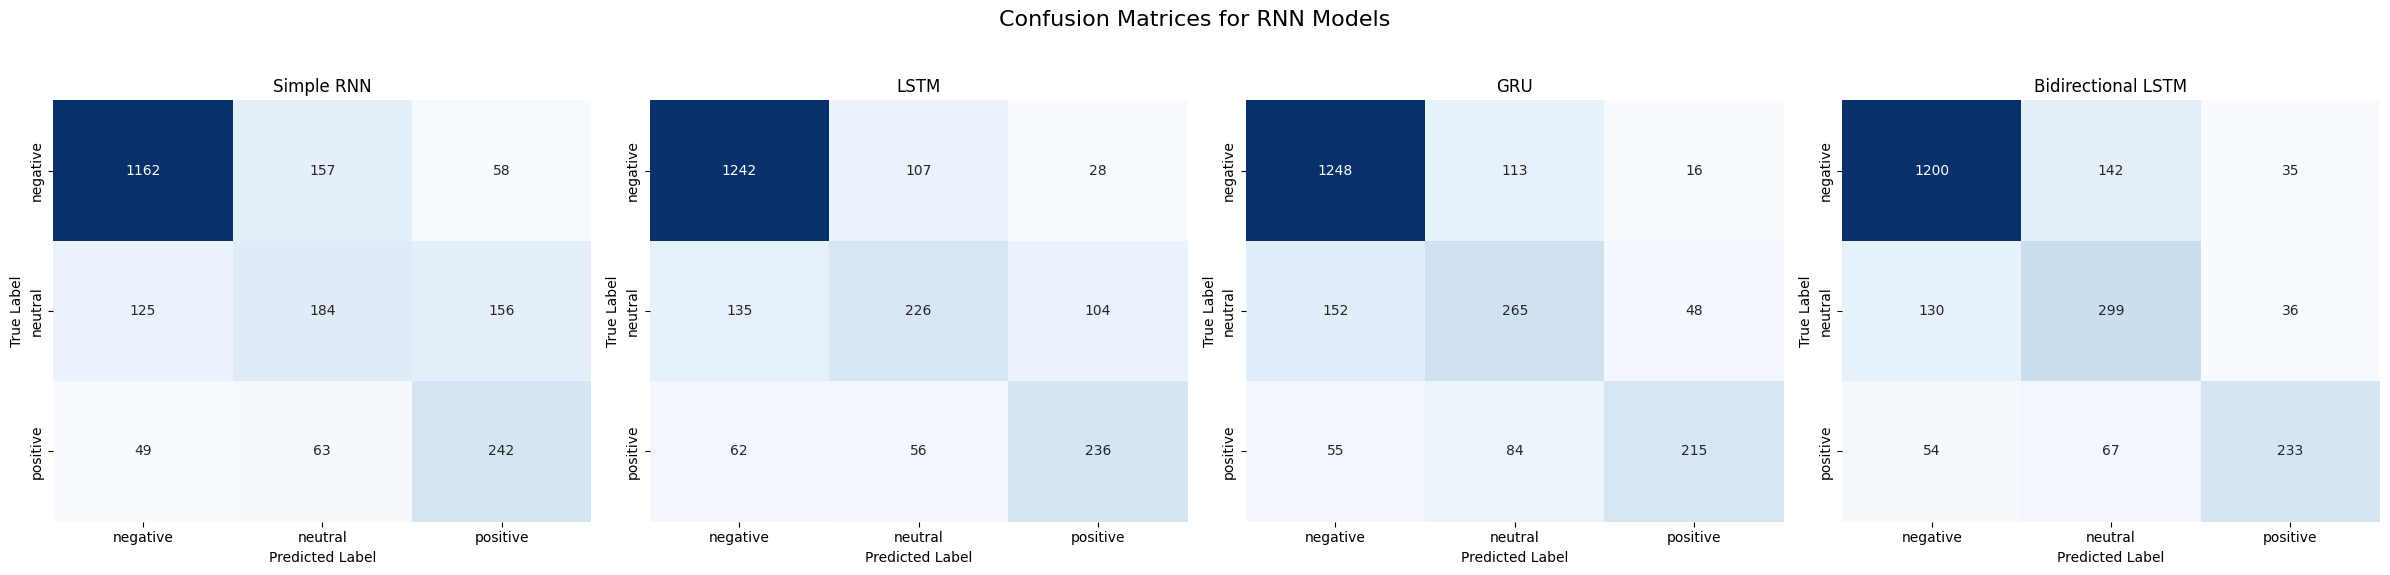

In [59]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Confusion Matrices for RNN Models', fontsize=16)

for i, (model_name, model) in enumerate(models.items()):
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{model_name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Most commonly misclassified class and reasoning:**

> Across all models, the **neutral** sentiment class appears to be the most commonly misclassified. This is evident from the relatively lower recall and precision for the neutral class in the classification reports, and visually confirmed by the confusion matrices where a significant portion of neutral tweets are predicted as negative. This could be due to the inherent ambiguity of neutral language, which often lacks strong positive or negative indicators, making it harder for models to distinguish from the more dominant 'negative' class, especially in an imbalanced dataset.

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

| Model | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run (before early stopping) |
|-------|---------------|----------------|------------------|------------------------------------|
| Simple RNN | 0.7231 | 0.63 | 968451 | 4 |
| LSTM | 0.7760 | 0.69 | 993219 | 5 |
| GRU | 0.7869 | 0.71 | 985155 | 7 |
| Bidirectional LSTM | 0.7887 | 0.73 | 1133315 | 6 |

Which model gave the **best accuracy-to-parameter ratio**? Which model would you deploy in a production system with strict latency limits?

**Fill in the table above. Then answer:**

- Best accuracy-to-parameter ratio: **GRU** (Accuracy / Parameters: 0.7869 / 985155 ≈ 7.99e-7)
- Production choice (latency-constrained): **GRU**. The GRU model offers a strong balance between performance (high test accuracy and Macro F1-score) and computational efficiency (fewer parameters than LSTM and Bidirectional LSTM). While Simple RNN has the fewest parameters, its performance is notably lower. The Bidirectional LSTM, despite having slightly higher accuracy and F1-score, has a significantly larger number of parameters, which would increase inference latency in a production setting. Hence, GRU presents a good compromise.

### ❓ Question 6.2 — Live Prediction Function

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]
```

Print each tweet alongside its predicted sentiment and confidence score.

In [60]:
def predict_sentiment(text, model, tokenizer, max_len, label_encoder, clean_text_func):
    """
    Predict sentiment for a raw tweet string.
    Returns: dict with 'sentiment' and 'confidence'
    """
    # 1. Clean the input text
    cleaned_text = clean_text_func(text)

    # 2. Tokenize and pad it to MAX_LEN
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

    # 3. Predict the sentiment class using the given model
    prediction = model.predict(padded_sequence, verbose=0)[0]
    predicted_class_idx = np.argmax(prediction)
    confidence = prediction[predicted_class_idx]

    # Convert predicted class index back to original label
    predicted_sentiment = label_encoder.inverse_transform([predicted_class_idx])[0]

    # 4. Returns a dictionary
    return {"sentiment": predicted_sentiment, "confidence": float(confidence)}


test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

# Identify the best performing model based on test accuracy
best_model_name = max(test_results, key=test_results.get)
best_model = models[best_model_name]

print(f"\nUsing the best performing model: {best_model_name} (Test Accuracy: {test_results[best_model_name]:.4f})\n")

# Run predictions
for tweet in test_tweets:
    result = predict_sentiment(tweet, best_model, tokenizer, MAX_LEN, label_encoder, clean_text)
    print(f"Tweet: '{tweet}'")
    print(f"Predicted Sentiment: {result['sentiment'].upper()} (Confidence: {result['confidence']:.2f})\n")



Using the best performing model: Bidirectional LSTM (Test Accuracy: 0.7887)

Tweet: '@SouthwestAir Thank you so much for the amazing service today! Best flight ever!'
Predicted Sentiment: POSITIVE (Confidence: 1.00)

Tweet: '@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.'
Predicted Sentiment: NEGATIVE (Confidence: 1.00)

Tweet: '@AmericanAir Flight delayed by 2 hours. No explanation given.'
Predicted Sentiment: NEGATIVE (Confidence: 0.99)

Tweet: '@Delta Just landed. Flight was on time, nothing special to report.'
Predicted Sentiment: NEGATIVE (Confidence: 0.97)

Tweet: '@JetBlue the crew was incredibly kind and the seats were comfortable!'
Predicted Sentiment: POSITIVE (Confidence: 0.84)



### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

> An imbalanced dataset, like the one here dominated by negative tweets, can lead to models that are biased towards the majority class. The model might achieve high overall accuracy by simply predicting the majority class, but perform poorly (low precision/recall/F1-score) on minority classes (positive and neutral tweets in this case). To address this, techniques like **oversampling** the minority classes (e.g., SMOTE), **undersampling** the majority class, using **class weights** in the loss function, or applying **focal loss** can be used to give more importance to the minority classes during training.

**2. Pre-trained embeddings vs trainable embeddings:**

> Using **pre-trained word embeddings** (like GloVe 100d) instead of a trainable Embedding layer would likely improve performance, especially on smaller datasets, by leveraging semantic relationships learned from vast external corpora. This provides a richer initial representation for words, helping the model generalize better and potentially converge faster. However, trainable embeddings can adapt specifically to the task's context, which might be beneficial for very large, domain-specific datasets.

**3. Transformer advantage and drawback vs LSTM/GRU:**

> One significant advantage of **Transformers** over LSTM/GRU for sentiment analysis is their ability to capture **long-range dependencies** more effectively through self-attention mechanisms and process sequences in parallel, leading to faster training on modern hardware. This often results in superior performance. A drawback, however, is their **higher computational cost and memory footprint** due to the large number of parameters, especially for longer sequences, making them slower for inference on resource-constrained devices compared to simpler RNNs.

---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

Starting manual grid search for GRU model...

Training GRU with Embed_Dim=32, Units=32, Dropout=0.2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  Val Accuracy: 0.7409

Training GRU with Embed_Dim=32, Units=32, Dropout=0.3
  Val Accuracy: 0.7573

Training GRU with Embed_Dim=32, Units=32, Dropout=0.5
  Val Accuracy: 0.6266

Training GRU with Embed_Dim=32, Units=64, Dropout=0.2
  Val Accuracy: 0.7587

Training GRU with Embed_Dim=32, Units=64, Dropout=0.3
  Val Accuracy: 0.7559

Training GRU with Embed_Dim=32, Units=64, Dropout=0.5
  Val Accuracy: 0.6954

Training GRU with Embed_Dim=32, Units=128, Dropout=0.2
  Val Accuracy: 0.7541

Training GRU with Embed_Dim=32, Units=128, Dropout=0.3
  Val Accuracy: 0.7655

Training GRU with Embed_Dim=32, Units=128, Dropout=0.5
  Val Accuracy: 0.6266

Training GRU with Embed_Dim=64, Units=32, Dropout=0.2
  Val Accuracy: 0.7614

Training GRU with Embed_Dim=64, Units=32, Dropout=0.3
  Val Accuracy: 0.7600

Training GRU with Embed_Dim=64, Units=32, Dropout=0.5
  Val Accuracy: 0.7127

Training GRU with Embed_Dim=64, Units=64, Dropout=0.2
  Val Accuracy: 0.7555

Training GRU with Embed_Dim=64, Units

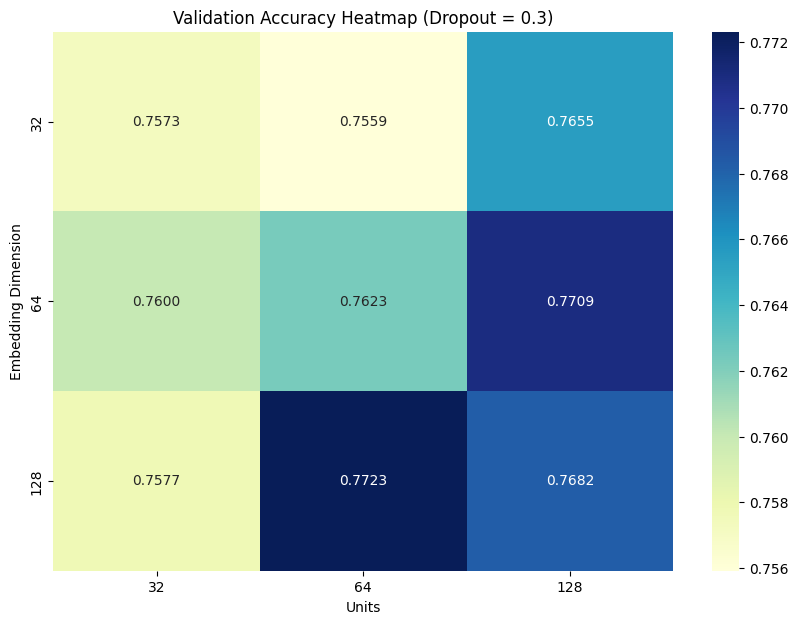


Best Hyperparameters found: {'embed_dim': 128, 'units': 64, 'dropout': 0.3}

Retraining the best GRU model with early stopping...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.6243 - loss: 0.9263 - val_accuracy: 0.6266 - val_loss: 0.9172
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.6301 - loss: 0.8980 - val_accuracy: 0.7040 - val_loss: 0.6985
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7399 - loss: 0.6187 - val_accuracy: 0.7518 - val_loss: 0.6145
Epoch 4/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8188 - loss: 0.4737 - val_accuracy: 0.7577 - val_loss: 0.6307
Epoch 5/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.8726 - loss: 0.3558 - val_accuracy: 0.7614 - val_loss: 0.7011
Epoch 6/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9043 - loss: 0.2715 - val_accuracy: 0.7600 - val_loss: 0.7340

Evaluating the best tuned GRU model on the test set...
Final Tuned GRU Model Test Accuracy: 0.7782
Final Tuned GRU Model Test Loss: 0.5754


In [65]:
# Choose GRU model for hyperparameter tuning
chosen_model_builder = build_gru # Using the GRU model builder function
model_name_prefix = 'tuned_gru'

embed_dims = [32, 64, 128]
units_list = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]

best_val_accuracy = 0
best_hparams = {}
all_results = []

print("Starting manual grid search for GRU model...")

# Create a dictionary to store validation accuracies for heatmap
heatmap_data = np.zeros((len(embed_dims), len(units_list)))

for i, embed_dim_val in enumerate(embed_dims):
    for j, units_val in enumerate(units_list):
        for dropout_val in dropout_list:
            print(f"\nTraining GRU with Embed_Dim={embed_dim_val}, Units={units_val}, Dropout={dropout_val}")

            # Temporarily update hyperparameters for the model builder
            original_EMBED_DIM = EMBED_DIM
            original_UNITS = UNITS
            original_DROPOUT_RATE = DROPOUT_RATE

            EMBED_DIM = embed_dim_val
            UNITS = units_val
            DROPOUT_RATE = dropout_val

            # Rebuild and compile the GRU model with current hyperparameters
            # The build_gru function needs to be updated to accept these new hparams or
            # fetch them from global scope (which is done here). For a cleaner approach,
            # build_gru could accept arguments.
            # For this exercise, we're relying on global scope modification.
            tuned_model = chosen_model_builder()

            # Train for 5 epochs without early stopping
            history = tuned_model.fit(
                X_train, y_train,
                epochs=5, # Train for 5 epochs as specified
                batch_size=BATCH_SIZE,
                validation_data=(X_val, y_val),
                verbose=0 # Suppress verbose output during grid search
            )

            val_accuracy = max(history.history['val_accuracy'])
            all_results.append({
                'embed_dim': embed_dim_val,
                'units': units_val,
                'dropout': dropout_val,
                'val_accuracy': val_accuracy
            })

            print(f"  Val Accuracy: {val_accuracy:.4f}")

            if dropout_val == 0.3: # Fix dropout for heatmap
                heatmap_data[i, j] = val_accuracy

            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                best_hparams = {
                    'embed_dim': embed_dim_val,
                    'units': units_val,
                    'dropout': dropout_val
                }

            # Restore original hyperparameters (important for subsequent uses of global values)
            EMBED_DIM = original_EMBED_DIM
            UNITS = original_UNITS
            DROPOUT_RATE = original_DROPOUT_RATE

print("\nGrid search complete.")

# 3. Print the top 3 best hyperparameter combinations
sorted_results = sorted(all_results, key=lambda x: x['val_accuracy'], reverse=True)
print("\nTop 3 best hyperparameter combinations:")
for result in sorted_results[:3]:
    print(f"  Embed_Dim: {result['embed_dim']}, Units: {result['units']}, Dropout: {result['dropout']}, Val Accuracy: {result['val_accuracy']:.4f}")

# 4. Plot a heatmap of val_accuracy across embed_dim vs units (fix dropout at 0.3)
plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu",
            xticklabels=units_list, yticklabels=embed_dims)
plt.title('Validation Accuracy Heatmap (Dropout = 0.3)')
plt.xlabel('Units')
plt.ylabel('Embedding Dimension')
plt.show()

print(f"\nBest Hyperparameters found: {best_hparams}")

# 5. Retrain the best model for 15 epochs with early stopping
print("\nRetraining the best GRU model with early stopping...")
EMBED_DIM = best_hparams['embed_dim']
UNITS = best_hparams['units']
DROPOUT_RATE = best_hparams['dropout']

best_gru_model = chosen_model_builder() # Rebuild with best hparams

best_model_callbacks = get_callbacks(f'{model_name_prefix}_best_tuned')

history_best_tuned = best_gru_model.fit(
    X_train, y_train,
    epochs=15, # Retrain for 15 epochs
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=best_model_callbacks,
    verbose=1
)

# Report final test accuracy
print("\nEvaluating the best tuned GRU model on the test set...")
test_loss_tuned, test_accuracy_tuned = best_gru_model.evaluate(X_test, y_test, verbose=0)
print(f"Final Tuned GRU Model Test Accuracy: {test_accuracy_tuned:.4f}")
print(f"Final Tuned GRU Model Test Loss: {test_loss_tuned:.4f}")

# Restore original hyperparameters after tuning (if needed for further code)
EMBED_DIM = original_EMBED_DIM
UNITS = original_UNITS
DROPOUT_RATE = original_DROPOUT_RATE